<a href="https://colab.research.google.com/github/Soukthavilay/data-science-shoppee-thailand/blob/main/Copy_of_KLTN_13_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.1. Install catboost , scikit-plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import scikitplot as skplt
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from catboost import CatBoostClassifier, Pool, cv, metrics
from catboost.utils import get_confusion_matrix

ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.12/dist-packages/scipy/__init__.py)

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Khoa_Luan/TuyChinh-5-TrainV.csv')
#data_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Khoa_Luan/TuyChinh-5-TestV.csv')

In [ ]:
cat_cols = data.columns
print('Kiểm tra Tần suất của các loại dữ liệu trong mỗi thuộc tính trong bảng: \n')
for col in cat_cols:
    print(f'======{col}======\n {data[col].value_counts()}\n')

Kiểm tra Tần suất của các loại dữ liệu trong mỗi thuộc tính trong bảng: 

======TUOI======
 44    68
50    67
48    67
40    65
39    64
49    64
43    61
47    55
46    54
37    53
54    52
32    51
52    50
45    48
42    48
38    47
35    44
51    43
55    43
53    40
33    40
41    39
34    38
36    36
30    33
29    31
31    30
27    25
56    23
26    18
28    18
57    17
58    14
60    12
24     9
59     7
21     6
25     6
19     5
22     5
23     3
18     2
20     2
Name: TUOI, dtype: int64

======KHUVUC======
 6    266
3    242
2    233
1    233
7    180
5    134
8    132
4     83
Name: KHUVUC, dtype: int64

======NGHENGHI======
 1    698
2    288
5    288
3    159
4     70
Name: NGHENGHI, dtype: int64

======DANTOC======
 1    1492
2      11
Name: DANTOC, dtype: int64

======TONGIAO======
 3    1312
1     176
2      13
4       2
Name: TONGIAO, dtype: int64

======HOCVAN======
 4    519
3    393
5    334
6    179
2     78
Name: HOCVAN, dtype: int64

======KINHTE======
 3    12

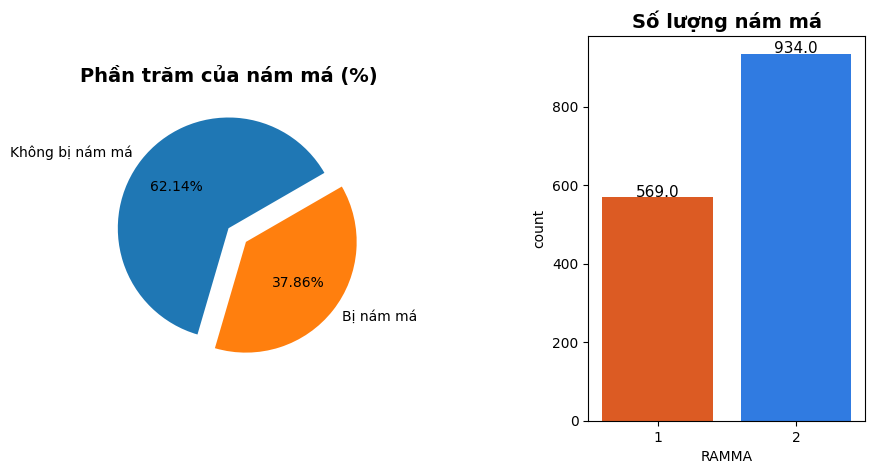

In [ ]:
# Tạo Figure mới với kích thước 10x5
fig = plt.figure(figsize=(10,5))

# Tạo khu vực vẽ biểu đồ thứ nhất trên cùng 1 hàng
ax1 = fig.add_subplot(1, 2, 1)

# Vẽ biểu đồ tròn
ax1.pie(pd.value_counts(data['RAMMA']), labels=['Không bị nám má', 'Bị nám má'], explode=[0, 0.2], startangle=30, autopct='%.2f%%')
ax1.set_title('Phần trăm của nám má (%)', fontsize=14, fontweight='bold')

# Tạo khu vực vẽ biểu đồ thứ hai trên cùng 1 hàng
ax2 = fig.add_subplot(1, 2, 2)

# Vẽ biểu đồ cột
sns.countplot(x='RAMMA', data=data, ax=ax2, palette=['#FB4F04', '#1377FE'])
for rect in ax2.patches:
    ax2.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
ax2.set_title('Số lượng nám má', fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.8)
# Hiển thị biểu đồ
plt.show()

<Axes: xlabel='RAMMA', ylabel='TUOI'>

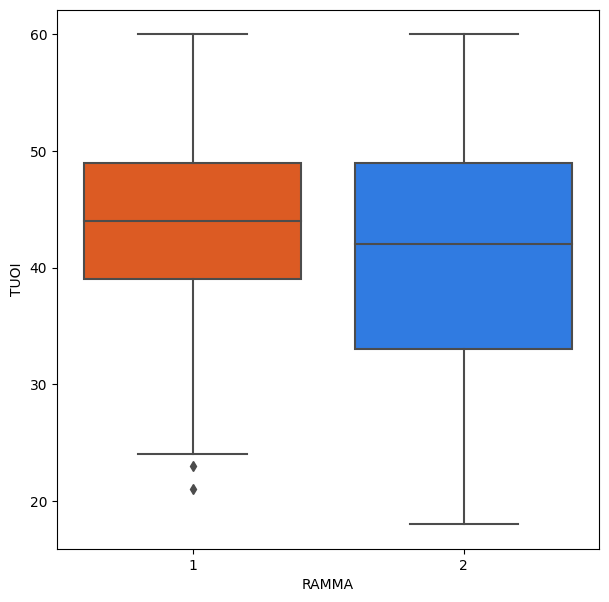

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=data,x='RAMMA',y='TUOI', palette=['#FB4F04','#1377FE'])

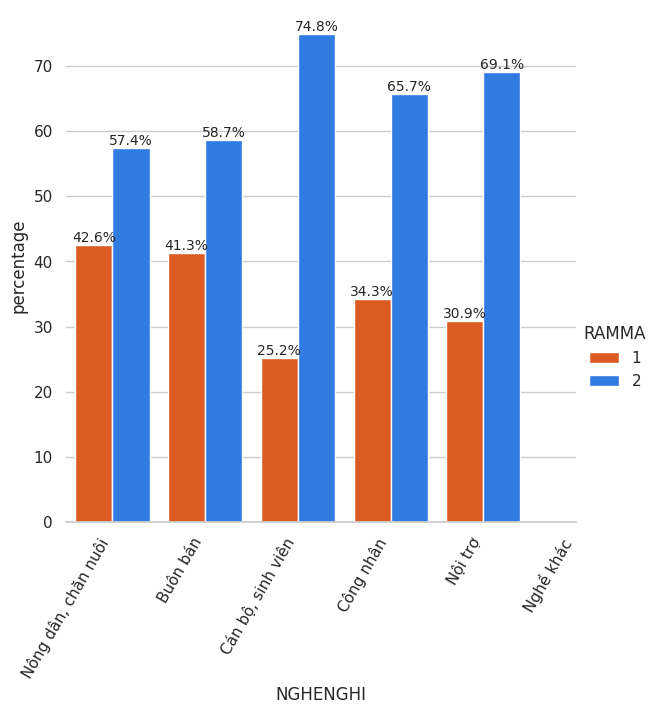

In [ ]:
# Calculate the percentage of each RAMMA category for each occupation
occupation_ramma_percentages = (data.groupby(['NGHENGHI', 'RAMMA']).size() /
                                data.groupby('NGHENGHI').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='NGHENGHI', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Nông dân, chăn nuôi','Buôn bán','Cán bộ, sinh viên','Công nhân','Nội trợ', 'Nghề khác'], rotation=60, ha='right')
g.despine(left=True)
g.set_xticklabels(rotation=60)
plt.show()

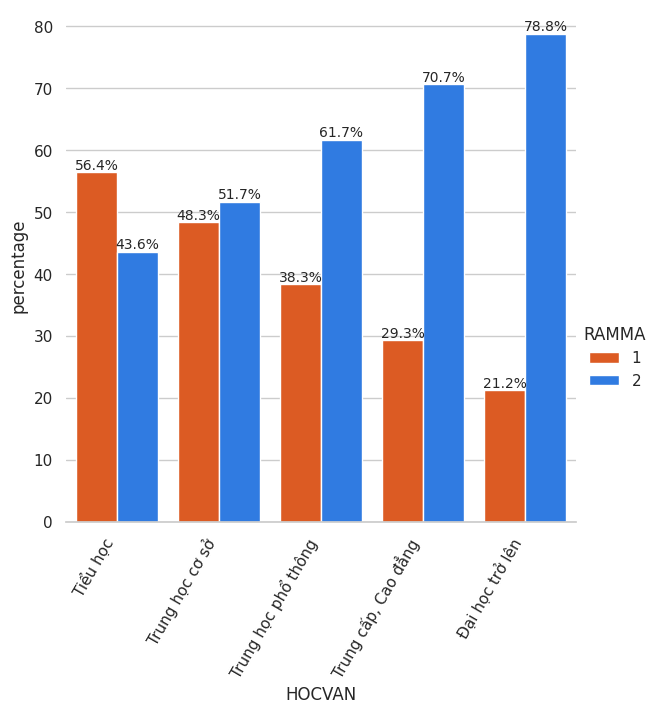

In [ ]:
# Calculate the percentage of each RAMMA category for each education
occupation_ramma_percentages = (data.groupby(['HOCVAN', 'RAMMA']).size() /
                                data.groupby('HOCVAN').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='HOCVAN', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
g.set_xticklabels(rotation=60)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Tiểu học','Trung học cơ sở','Trung học phổ thông','Trung cấp, Cao đẳng','Đại học trở lên'],ha='right')
plt.show()

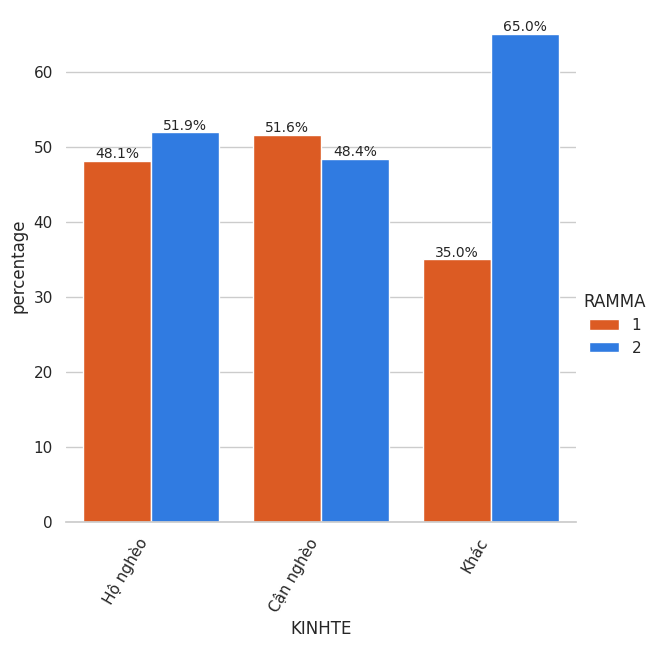

In [ ]:
# tính tỉ lệ của nhũng người bị nám má của từng kinh tế
occupation_ramma_percentages = (data.groupby(['KINHTE', 'RAMMA']).size() /
                                data.groupby('KINHTE').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='KINHTE', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1, 2], labels=['Hộ nghèo','Cận nghèo','Khác'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

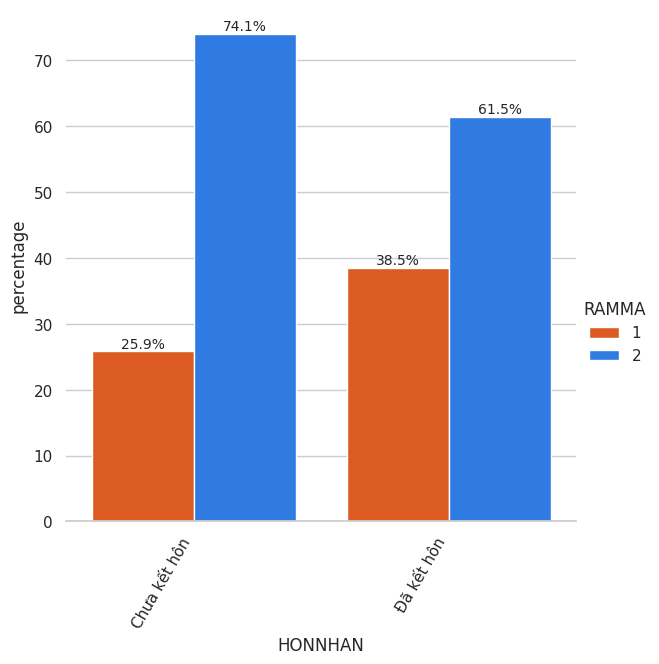

In [ ]:

occupation_ramma_percentages = (data.groupby(['HONNHAN', 'RAMMA']).size() /
                                data.groupby('HONNHAN').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='HONNHAN', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1], labels=['Chưa kết hôn','Đã kết hôn'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

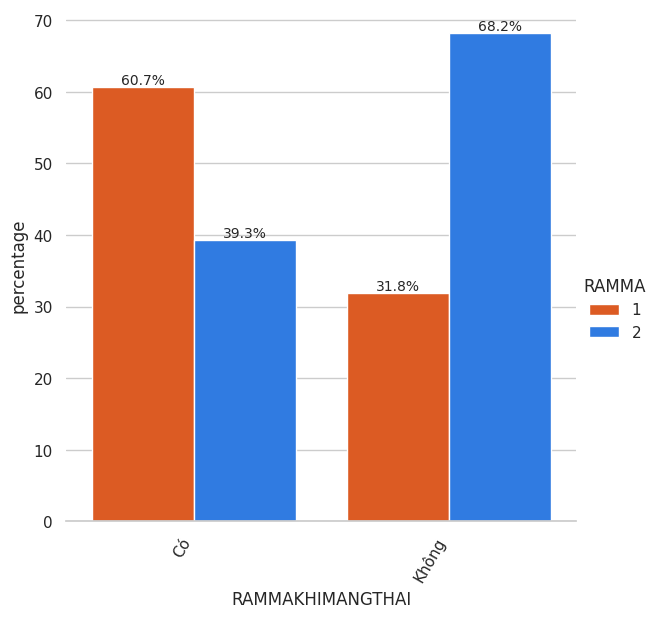

In [ ]:

occupation_ramma_percentages = (data.groupby(['RAMMAKHIMANGTHAI', 'RAMMA']).size() /
                                data.groupby('RAMMAKHIMANGTHAI').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='RAMMAKHIMANGTHAI', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1], labels=['Có','Không'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

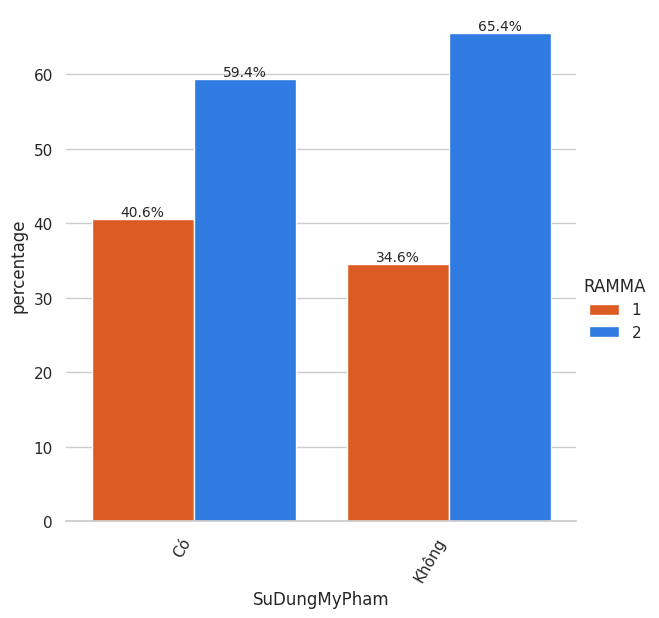

In [ ]:
occupation_ramma_percentages = (data.groupby(['SuDungMyPham', 'RAMMA']).size() /
                                data.groupby('SuDungMyPham').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='SuDungMyPham', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1], labels=['Có','Không'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

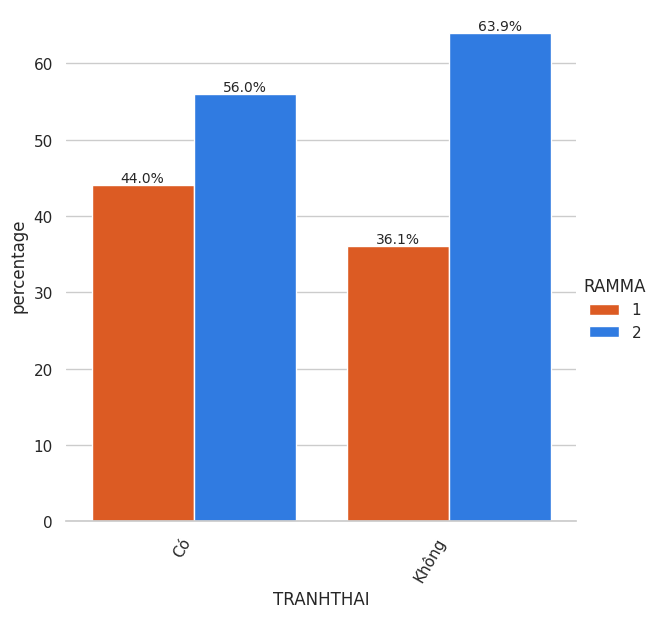

In [ ]:
occupation_ramma_percentages = (data.groupby(['TRANHTHAI', 'RAMMA']).size() /
                                data.groupby('TRANHTHAI').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='TRANHTHAI', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1], labels=['Có','Không'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

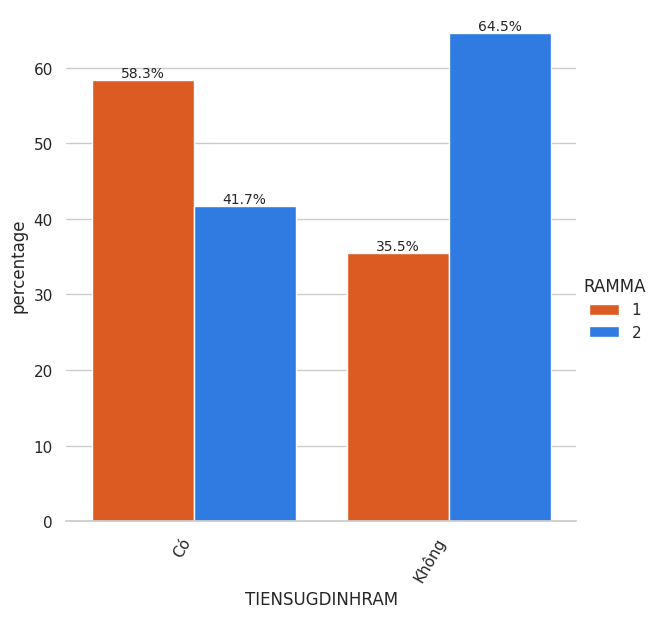

In [ ]:
occupation_ramma_percentages = (data.groupby(['TIENSUGDINHRAM', 'RAMMA']).size() /
                                data.groupby('TIENSUGDINHRAM').size() * 100)

# Convert the resulting pandas Series to a DataFrame and reset the index
occupation_ramma_percentages_df = occupation_ramma_percentages.reset_index(name='percentage')

# Plot the data using a seaborn barplot
sns.set(style='whitegrid')
g = sns.catplot(x='TIENSUGDINHRAM', y='percentage', hue='RAMMA', data=occupation_ramma_percentages_df,
                kind='bar', height=6, aspect=1, palette=['#FB4F04','#1377FE'])
ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
g.despine(left=True)
plt.xticks(ticks=[0, 1], labels=['Có','Không'],ha='right', rotation=60)
g.set_xticklabels(rotation=60)
plt.show()

<Axes: xlabel='RAMMA', ylabel='SOLANMANGTHAI'>

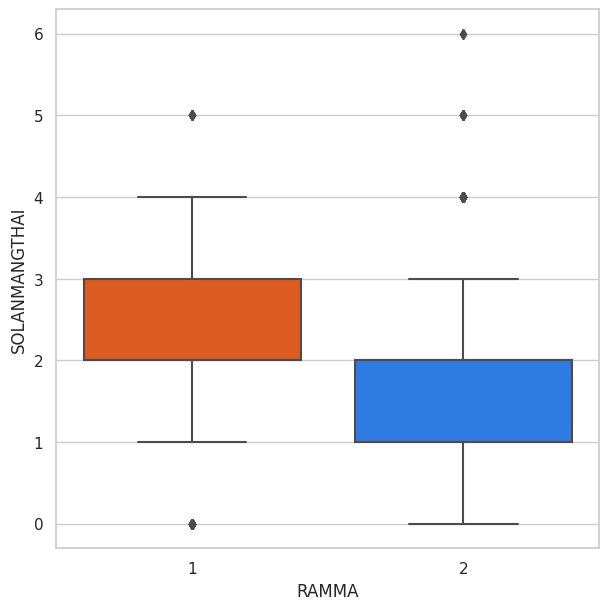

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=data,x='RAMMA',y='SOLANMANGTHAI', palette=['#FB4F04','#1377FE'])

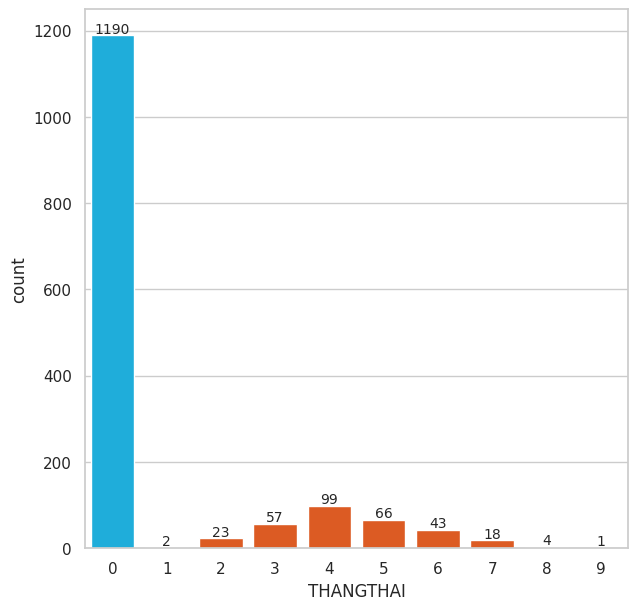

In [ ]:
plt.figure(figsize=(7,7))
ax = sns.countplot(data=data,x='THANGTHAI',
                   palette=['#00BDF9', '#FB4F04', '#FB4F04', '#FB4F04','#FB4F04', '#FB4F04', '#FB4F04', '#FB4F04','#FB4F04'])

for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.4, p.get_height()+5), ha='center', fontsize=10)
plt.show()

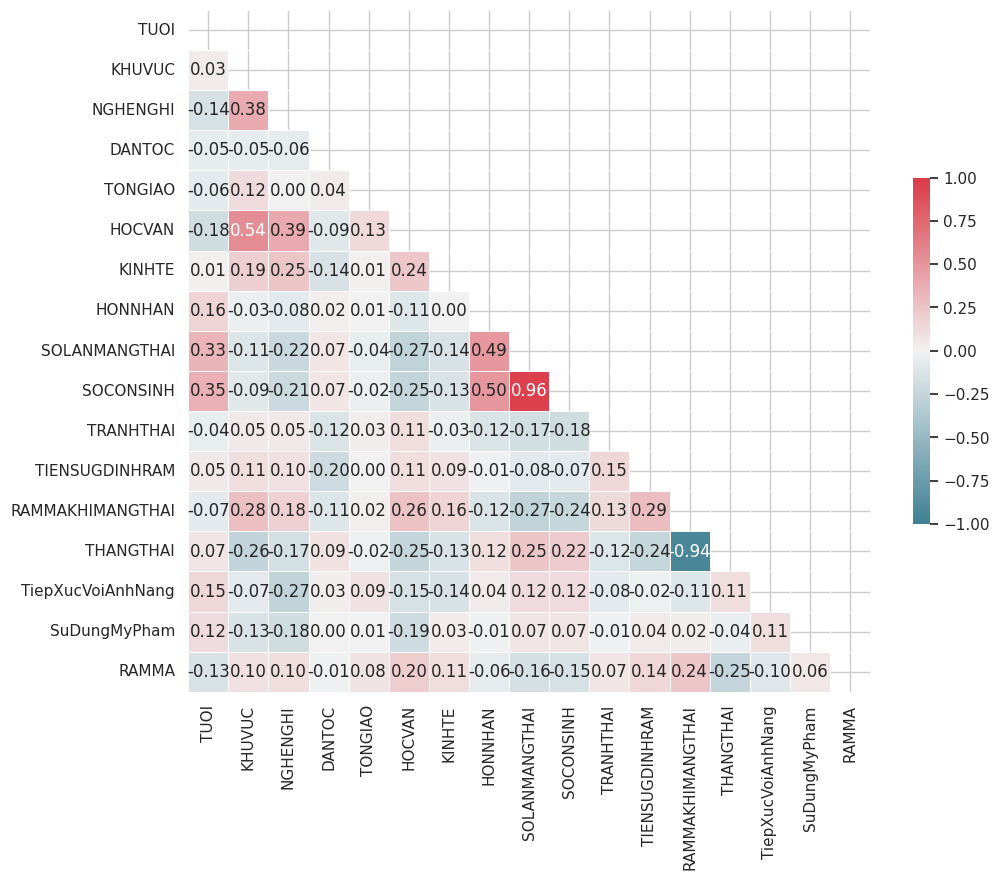

In [ ]:
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1.0, vmin= -1.0, center=0, square=True,linewidths=.5, cbar_kws={"shrink": .5}, fmt = '.2f', annot = True)
plt.savefig('Correlation plot.png', format='png')
plt.show()

<Axes: >

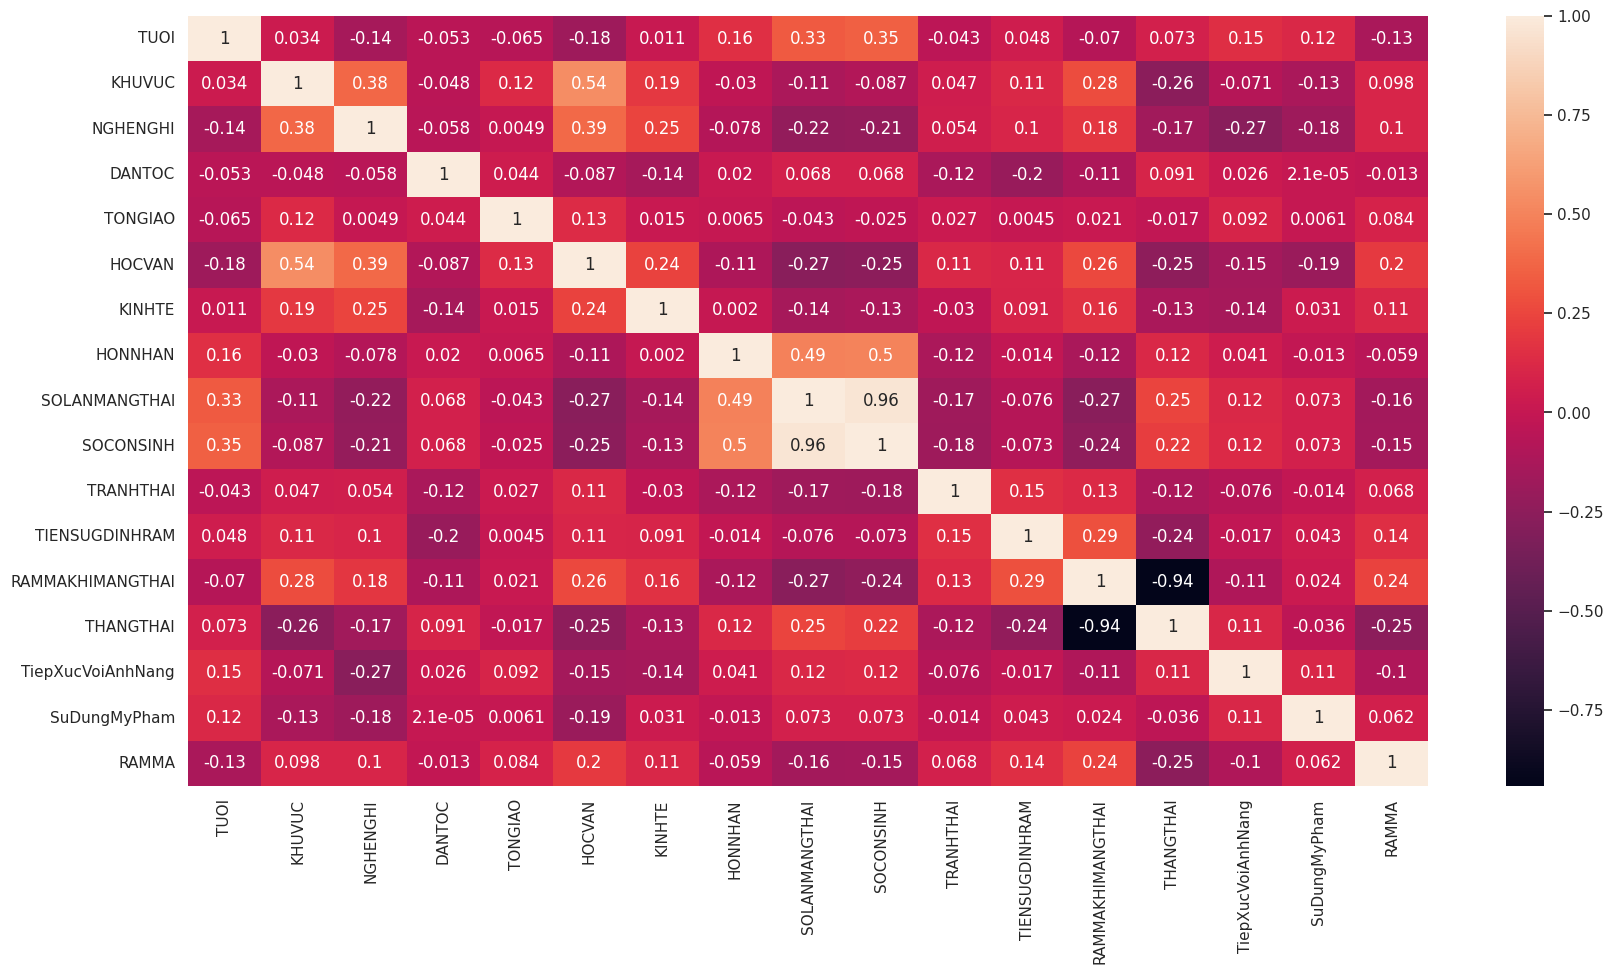

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(),annot=True)

In [ ]:
#@title Default title text


#X_train = data.drop('RAMMA', axis=1)
#y_train = data.RAMMA
#X_test = data_test.drop('RAMMA', axis=1)
#y_test = data_test.RAMMA

In [ ]:
X = data.drop('RAMMA', axis=1)
y = data.RAMMA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)


In [ ]:
# Tìm các cột có kiểu dữ liệu không phải float để xử lý nhãn rời rạc
cat_features = np.where(X_train.dtypes != float)[0]
cat_features

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

## 3.2. Huấn luyện mô hình Catboost

In [ ]:
# Tạo mô hình CatBoostClassifier với 1000 vòng lặp và dùng Logloss
cb_model1 = CatBoostClassifier(iterations = 1000, loss_function = 'Logloss')

In [ ]:
cb_model1.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model = True
);

Learning rate set to 0.035044
0:	learn: 0.6863727	test: 0.6906110	best: 0.6906110 (0)	total: 56.8ms	remaining: 56.8s
1:	learn: 0.6823963	test: 0.6891904	best: 0.6891904 (1)	total: 62.2ms	remaining: 31s
2:	learn: 0.6757119	test: 0.6872019	best: 0.6872019 (2)	total: 71.1ms	remaining: 23.6s
3:	learn: 0.6690489	test: 0.6816766	best: 0.6816766 (3)	total: 79.4ms	remaining: 19.8s
4:	learn: 0.6636255	test: 0.6770668	best: 0.6770668 (4)	total: 85.7ms	remaining: 17.1s
5:	learn: 0.6594570	test: 0.6772138	best: 0.6770668 (4)	total: 92ms	remaining: 15.2s
6:	learn: 0.6548982	test: 0.6757282	best: 0.6757282 (6)	total: 97.8ms	remaining: 13.9s
7:	learn: 0.6505964	test: 0.6724599	best: 0.6724599 (7)	total: 105ms	remaining: 13s
8:	learn: 0.6459297	test: 0.6709914	best: 0.6709914 (8)	total: 112ms	remaining: 12.3s
9:	learn: 0.6418442	test: 0.6669199	best: 0.6669199 (9)	total: 120ms	remaining: 11.8s
10:	learn: 0.6378524	test: 0.6632139	best: 0.6632139 (10)	total: 127ms	remaining: 11.4s
11:	learn: 0.6347100	

In [ ]:
#kiểm tra độ chính xác của cb_model1
print(cb_model1.score(X_test,y_test))

0.8458498023715415


In [ ]:
#tạo một dataframe mới để lưu kết quả dự đoán và nhãn của tập test
model_result = pd.DataFrame(columns=['result', 'label'])
model_result['result'] = cb_model1.predict(X_test)
model_result['label'] = np.asarray(y_test.copy())
# In ra kết quả dự đoán và thực tế trên tập X_test
model_result[['result','label']]

,result,label
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
248,2,2
249,2,2
250,2,2
251,2,2


Classification report:
               precision    recall  f1-score   support

           1       0.95      0.73      0.82       124
           2       0.78      0.96      0.86       129

    accuracy                           0.85       253
   macro avg       0.87      0.84      0.84       253
weighted avg       0.86      0.85      0.84       253

_____________________________________________________________________________________________


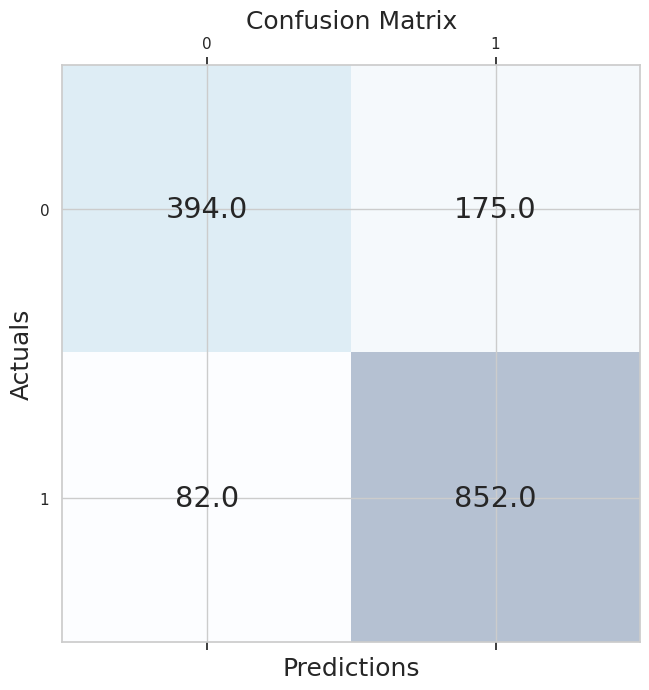

In [ ]:
# Tạo đối tượng Pool
train_pool = Pool(X_train, y_train, cat_features=cat_features)
y_pred_cb_model1 = cb_model1.predict(X_test)
# Tính toán classification report và confusion matrix
print("Classification report:\n", classification_report(y_test,y_pred_cb_model1))

print("_____________________________________________________________________________________________")

# Compute the confusion matrix
conf_matrix = get_confusion_matrix(cb_model1, train_pool)

# Create a figure and axis object with a specific size
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Plot the confusion matrix as a matrix of colored squares
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)

# Add text labels to each square of the matrix
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

# Set the x and y axis labels and title
ax.set_xlabel('Predictions', fontsize=18)
ax.set_ylabel('Actuals', fontsize=18)
ax.set_title('Confusion Matrix', fontsize=18)

# Show the plot
plt.show()

In [ ]:
# Tạo đối tượng Pool để sử dụng trong việc tính toán độ quan trọng của các biến
train_pool = Pool(X_train, y_train, cat_features=cat_features)

# Tính toán độ quan trọng của các biến
feature_importances = cb_model1.get_feature_importance(train_pool)
feature_names = X_train.columns

# In ra các biến và độ quan trọng của chúng theo thứ tự giảm dần
for score, name in sorted(zip(feature_importances, feature_names), reverse=True):
    print('{}: {}'.format(name, score))

NameError: name 'Pool' is not defined

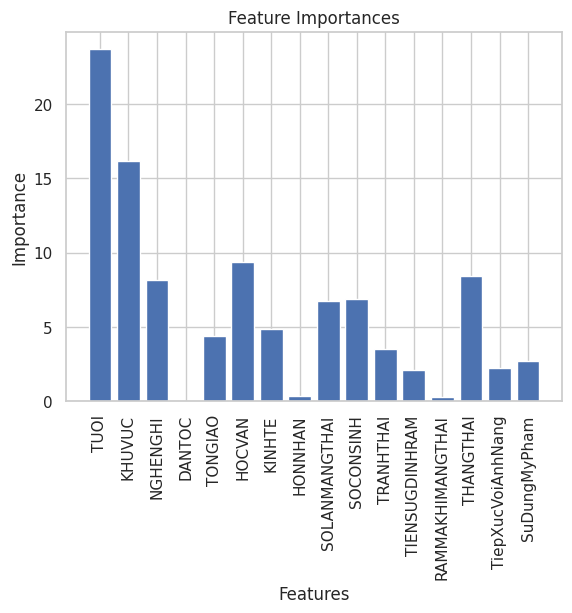

In [ ]:
# Tạo list các đặc trưng và độ quan trọng tương ứng
features = feature_names
importances = feature_importances
# Vẽ biểu đồ cột
plt.bar(range(len(features)), importances)
plt.xticks(range(len(features)), features, rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()

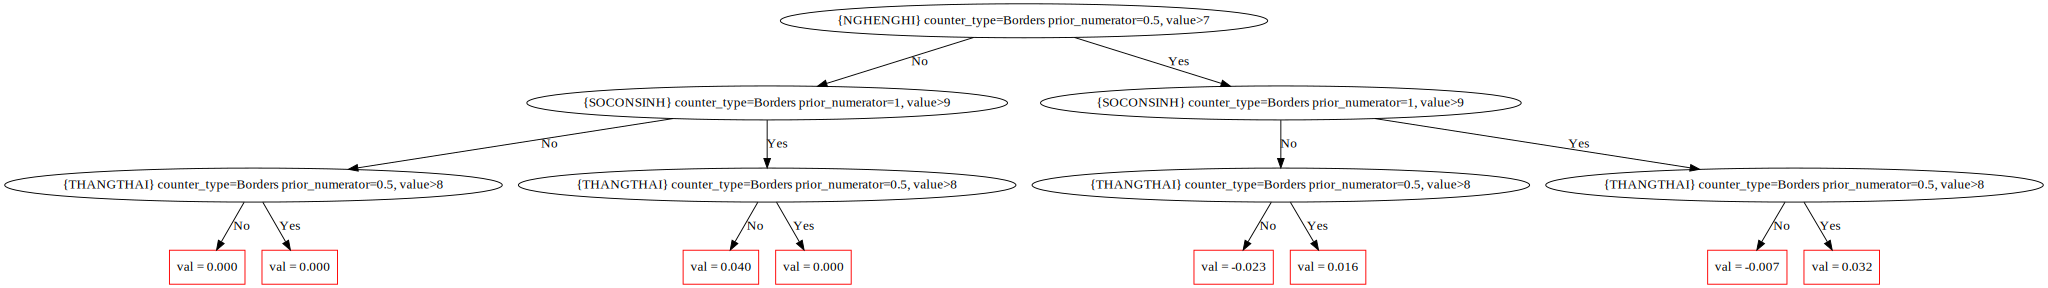

In [ ]:
cb_model1.plot_tree(
tree_idx=1,
pool=train_pool # "pool" is required parameter for trees with one hot features
)

In [ ]:
cb_model1.save_model("cb_model")

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

[0]	validation_0-error:0.25025	validation_0-logloss:0.69031	validation_1-error:0.29839	validation_1-logloss:0.69070
[1]	validation_0-error:0.24926	validation_0-logloss:0.68758	validation_1-error:0.29637	validation_1-logloss:0.68842
[2]	validation_0-error:0.25025	validation_0-logloss:0.68489	validation_1-error:0.29839	validation_1-logloss:0.68610
[3]	validation_0-error:0.25124	validation_0-logloss:0.68225	validation_1-error:0.29839	validation_1-logloss:0.68383
[4]	validation_0-error:0.24926	validation_0-logloss:0.67963	validation_1-error:0.29839	validation_1-logloss:0.68172
[5]	validation_0-error:0.25025	validation_0-logloss:0.67708	validation_1-error:0.30040	validation_1-logloss:0.67959
[6]	validation_0-error:0.24926	validation_0-logloss:0.67456	validation_1-error:0.29637	validation_1-logloss:0.67757
[7]	validation_0-error:0.24926	validation_0-logloss:0.67210	validation_1-error:0.29839	validation_1-logloss:0.67553
[8]	validation_0-error:0.25323	validation_0-logloss:0.66967	validation_1

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[29]	validation_0-error:0.24032	validation_0-logloss:0.62614	validation_1-error:0.30040	validation_1-logloss:0.63916
[30]	validation_0-error:0.24131	validation_0-logloss:0.62439	validation_1-error:0.30040	validation_1-logloss:0.63774
[31]	validation_0-error:0.24032	validation_0-logloss:0.62263	validation_1-error:0.30040	validation_1-logloss:0.63639
[32]	validation_0-error:0.23535	validation_0-logloss:0.62093	validation_1-error:0.30645	validation_1-logloss:0.63545
[33]	validation_0-error:0.23833	validation_0-logloss:0.61922	validation_1-error:0.30242	validation_1-logloss:0.63414
[34]	validation_0-error:0.23535	validation_0-logloss:0.61748	validation_1-error:0.30645	validation_1-logloss:0.63300
[35]	validation_0-error:0.22840	validation_0-logloss:0.61584	validation_1-error:0.30242	validation_1-logloss:0.63211
[36]	validation_0-error:0.23138	validation_0-logloss:0.61427	validation_1-error:0.29839	validation_1-logloss:0.63092
[37]	validation_0-error:0.23039	validation_0-logloss:0.61256	val

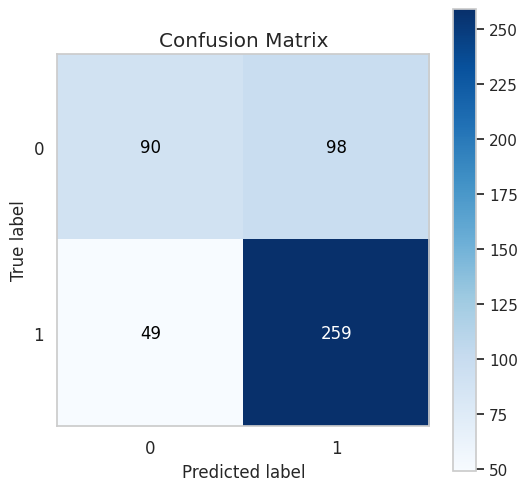

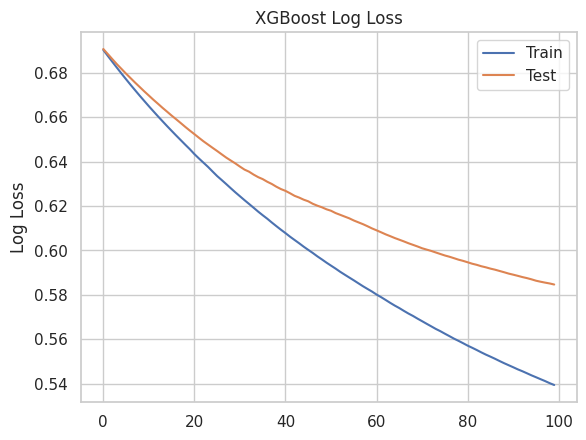

In [ ]:
parameters = {'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}
model = XGBClassifier(**parameters)
eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(X_train, y_train,eval_metric=["error", "logloss"], eval_set=eval_set, verbose=True)

# Evaluate the skill of the Trained model
pred_Class          = model.predict(X_test)
pred_proba          = model.predict_proba(X_test)
acc                 = accuracy_score(y_test, pred_Class)
classReport         = classification_report(y_test, pred_Class)
confMatrix          = confusion_matrix(y_test, pred_Class)
kappa_score         = cohen_kappa_score(y_test, pred_Class)

print(); print('Evaluation of the trained model: (Đánh giá mô hình đã huấn luyện) ')
print(); print('Accuracy (Độ chính xác) : ', acc)
print(); print('Kappa Score (Hệ số Kappa) : ', kappa_score)
print(); print('Confusion Matrix (Ma trận nhầm lẫn) :\n', confMatrix)
print(); print('Classification Report (Báo cáo phân loại) :\n',classReport)
pred_proba = model.predict_proba(X_test)
# Confusion matrix
skplt.metrics.plot_confusion_matrix(y_test,pred_Class,figsize=(6,6)); plt.show()
# make predictions for test data
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]
# retrieve performance metrics
results = model.evals_result()
epochs = len(results['validation_0']['error'])
x_axis = range(0, epochs)
# plot log loss
fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['logloss'], label='Train')
ax.plot(x_axis, results['validation_1']['logloss'], label='Test')
ax.legend()
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.savefig('plot log loss model.png', format='png');plt.show()